In [2]:
import copy
import pickle
import inspect
from functools import partial
from centrex_trajectories.data_structures import Velocities, Coordinates, Trajectories
from pyparsing import Dict
from lens_scan_function import generate_vz_distribution, generate_dist_before_lens, lens_scan_function_with_input_before_lens, lens_scan_function_0kV
from gain_vs_height_simulation import process_single_trajectories, process_single_trajectories_serial, process_single_trajectories_parallel
import cupy as cp
from pathlib import Path
from joblib import Parallel, delayed, parallel_backend
from typing import Union, Any
import gc
import logging

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from rich import progress
from scipy import constants

from rich.progress import (
    Progress,
    BarColumn,
    TextColumn,
    TransferSpeedColumn,
    TimeRemainingColumn,
)
plt.rcParams.update({"font.size": 10})
from uncertainties import ufloat, unumpy

## Signal Vs Height  experimental data

In [3]:
from uncertainties import ufloat
from scipy.interpolate import interp1d
signal_vs_height_short = {
    0.0: {
        1.0: ufloat(0.137, 0.0035),
        3.0: ufloat(0.218, 0.0089),
        5.0: ufloat(0.247, 0.011),
        7.0: ufloat(0.226, 0.0073),
        9.0: ufloat(0.29, 0.013),
        11.0: ufloat(0.278, 0.011),
        13.0: ufloat(0.322, 0.011),
        15.0: ufloat(0.331, 0.01),
        17.0: ufloat(0.341, 0.022),
        19.0: ufloat(0.413, 0.018),
        21.0: ufloat(0.426, 0.019),
        23.0: ufloat(0.464, 0.023),
        25.0: ufloat(0.386, 0.023),
        27.0: ufloat(0.417, 0.0094),
        29.0: ufloat(0.485, 0.025),
        31.0: ufloat(0.481, 0.015),
        33.0: ufloat(0.56, 0.025),
        35.0: ufloat(0.494, 0.023),
        37.0: ufloat(0.41, 0.0057),
        39.0: ufloat(0.374, 0.013),
        41.0: ufloat(0.347, 0.016),
        43.0: ufloat(0.362, 0.0086),
        45.0: ufloat(0.371, 0.026),
        47.0: ufloat(0.264, 0.015),
        49.0: ufloat(0.105, 0.0059)
    },
}

signal_vs_height = {
    0.0: {
        1.0: ufloat(0.0176, 0.0054),
        3.0: ufloat(0.0395, 0.0048),
        5.0: ufloat(0.0357, 0.0057),
        7.0: ufloat(0.0451, 0.0024),
        9.0: ufloat(0.0434, 0.0019),
        11.0: ufloat(0.0467, 0.0038),
        13.0: ufloat(0.0516, 0.0031),
        15.0: ufloat(0.0532, 0.004),
        17.0: ufloat(0.0572, 0.0074),
        19.0: ufloat(0.0656, 0.0053),
        21.0: ufloat(0.0622, 0.0045),
        23.0: ufloat(0.0524, 0.004),
        25.0: ufloat(0.0577, 0.0022),
        27.0: ufloat(0.058, 0.0039),
        29.0: ufloat(0.0611, 0.0049),
        31.0: ufloat(0.0569, 0.004),
        33.0: ufloat(0.0509, 0.0048),
        35.0: ufloat(0.046, 0.0055),
        37.0: ufloat(0.0489, 0.0077),
        39.0: ufloat(0.0463, 0.0048),
        41.0: ufloat(0.0388, 0.0046),
        43.0: ufloat(0.0404, 0.0049),
        45.0: ufloat(0.0384, 0.0075),
        47.0: ufloat(0.031, 0.0042),
        49.0: ufloat(0.0259, 0.0036)
    },
    20.0: {
        1.0: ufloat(0.0482, 0.0049),
        3.0: ufloat(0.132, 0.0087),
        5.0: ufloat(0.164, 0.0041),
        7.0: ufloat(0.202, 0.007),
        9.0: ufloat(0.232, 0.0064),
        11.0: ufloat(0.254, 0.01),
        13.0: ufloat(0.316, 0.0086),
        15.0: ufloat(0.329, 0.016),
        17.0: ufloat(0.401, 0.017),
        19.0: ufloat(0.401, 0.017),
        21.0: ufloat(0.403, 0.02),
        23.0: ufloat(0.448, 0.026),
        25.0: ufloat(0.435, 0.019),
        27.0: ufloat(0.371, 0.021),
        29.0: ufloat(0.418, 0.02),
        31.0: ufloat(0.383, 0.018),
        33.0: ufloat(0.356, 0.017),
        35.0: ufloat(0.309, 0.013),
        37.0: ufloat(0.258, 0.0074),
        39.0: ufloat(0.241, 0.011),
        41.0: ufloat(0.204, 0.0055),
        43.0: ufloat(0.171, 0.0076),
        45.0: ufloat(0.134, 0.0069),
        47.0: ufloat(0.123, 0.0056),
        49.0: ufloat(0.107, 0.0032)
    },
    22.5: {
        1.0: ufloat(0.0485, 0.0059),
        3.0: ufloat(0.147, 0.0054),
        5.0: ufloat(0.176, 0.004),
        7.0: ufloat(0.215, 0.005),
        9.0: ufloat(0.257, 0.0065),
        11.0: ufloat(0.311, 0.0065),
        13.0: ufloat(0.367, 0.0073),
        15.0: ufloat(0.457, 0.006),
        17.0: ufloat(0.557, 0.015),
        19.0: ufloat(0.67, 0.019),
        21.0: ufloat(0.698, 0.031),
        23.0: ufloat(0.716, 0.035),
        25.0: ufloat(0.725, 0.019),
        27.0: ufloat(0.72, 0.022),
        29.0: ufloat(0.688, 0.022),
        31.0: ufloat(0.576, 0.017),
        33.0: ufloat(0.542, 0.0074),
        35.0: ufloat(0.476, 0.018),
        37.0: ufloat(0.387, 0.0072),
        39.0: ufloat(0.33, 0.01),
        41.0: ufloat(0.269, 0.0065),
        43.0: ufloat(0.2, 0.0049),
        45.0: ufloat(0.169, 0.0061),
        47.0: ufloat(0.137, 0.0065),
        49.0: ufloat(0.112, 0.0056)
    },
    26.25: {
        1.0: ufloat(0.0502, 0.0067),
        3.0: ufloat(0.154, 0.0094),
        5.0: ufloat(0.169, 0.0083),
        7.0: ufloat(0.2, 0.0031),
        9.0: ufloat(0.248, 0.0031),
        11.0: ufloat(0.299, 0.0048),
        13.0: ufloat(0.366, 0.0076),
        15.0: ufloat(0.459, 0.0037),
        17.0: ufloat(0.533, 0.0052),
        19.0: ufloat(0.625, 0.0083),
        21.0: ufloat(0.705, 0.0096),
        23.0: ufloat(0.766, 0.0095),
        25.0: ufloat(0.833, 0.0073),
        27.0: ufloat(0.821, 0.0064),
        29.0: ufloat(0.763, 0.0084),
        31.0: ufloat(0.695, 0.0088),
        33.0: ufloat(0.626, 0.0071),
        35.0: ufloat(0.547, 0.0082),
        37.0: ufloat(0.454, 0.011),
        39.0: ufloat(0.355, 0.0059),
        41.0: ufloat(0.283, 0.0067),
        43.0: ufloat(0.221, 0.01),
        45.0: ufloat(0.185, 0.0044),
        47.0: ufloat(0.153, 0.0076),
        49.0: ufloat(0.119, 0.0047)
    },
    30.0: {
        1.0: ufloat(0.0488, 0.0068),
        3.0: ufloat(0.129, 0.0046),
        5.0: ufloat(0.149, 0.0036),
        7.0: ufloat(0.176, 0.0035),
        9.0: ufloat(0.194, 0.0028),
        11.0: ufloat(0.206, 0.0052),
        13.0: ufloat(0.277, 0.0052),
        15.0: ufloat(0.319, 0.0073),
        17.0: ufloat(0.352, 0.01),
        19.0: ufloat(0.42, 0.012),
        21.0: ufloat(0.442, 0.011),
        23.0: ufloat(0.535, 0.0053),
        25.0: ufloat(0.514, 0.016),
        27.0: ufloat(0.524, 0.019),
        29.0: ufloat(0.55, 0.013),
        31.0: ufloat(0.486, 0.019),
        33.0: ufloat(0.422, 0.013),
        35.0: ufloat(0.389, 0.012),
        37.0: ufloat(0.359, 0.0097),
        39.0: ufloat(0.27, 0.0092),
        41.0: ufloat(0.255, 0.0053),
        43.0: ufloat(0.202, 0.0059),
        45.0: ufloat(0.166, 0.0064),
        47.0: ufloat(0.164, 0.0074),
        49.0: ufloat(0.115, 0.0042)
    }
}

signal_vs_height_top = {
    0.0: {
        1.0: ufloat(0.0202, 0.01),
        3.0: ufloat(0.0428, 0.0092),
        5.0: ufloat(0.0303, 0.011),
        7.0: ufloat(0.0425, 0.0044),
        9.0: ufloat(0.0411, 0.0033),
        11.0: ufloat(0.0477, 0.0067),
        13.0: ufloat(0.0558, 0.0052),
        15.0: ufloat(0.0515, 0.0074),
        17.0: ufloat(0.0538, 0.014),
        19.0: ufloat(0.0594, 0.0079),
        21.0: ufloat(0.0611, 0.0066),
        23.0: ufloat(0.0435, 0.0062),
        25.0: ufloat(0.0509, 0.0036),
        27.0: ufloat(0.0528, 0.006),
        29.0: ufloat(0.0574, 0.0061),
        31.0: ufloat(0.0517, 0.0057),
        33.0: ufloat(0.0451, 0.0051),
        35.0: ufloat(0.0439, 0.0047),
        37.0: ufloat(0.049, 0.0033),
        39.0: ufloat(0.0446, 0.0038),
        41.0: ufloat(0.0385, 0.004),
        43.0: ufloat(0.0353, 0.0034),
        45.0: ufloat(0.04, 0.0018),
        47.0: ufloat(0.0361, 0.002),
        49.0: ufloat(0.0257, 0.0026)
    },
    20.0: {
        1.0: ufloat(0.0454, 0.0095),
        3.0: ufloat(0.126, 0.014),
        5.0: ufloat(0.159, 0.0055),
        7.0: ufloat(0.194, 0.01),
        9.0: ufloat(0.228, 0.0068),
        11.0: ufloat(0.246, 0.015),
        13.0: ufloat(0.308, 0.012),
        15.0: ufloat(0.31, 0.021),
        17.0: ufloat(0.386, 0.024),
        19.0: ufloat(0.374, 0.025),
        21.0: ufloat(0.386, 0.028),
        23.0: ufloat(0.429, 0.034),
        25.0: ufloat(0.414, 0.025),
        27.0: ufloat(0.351, 0.028),
        29.0: ufloat(0.395, 0.028),
        31.0: ufloat(0.354, 0.022),
        33.0: ufloat(0.331, 0.022),
        35.0: ufloat(0.284, 0.015),
        37.0: ufloat(0.239, 0.0061),
        39.0: ufloat(0.217, 0.0095),
        41.0: ufloat(0.185, 0.0064),
        43.0: ufloat(0.151, 0.0089),
        45.0: ufloat(0.125, 0.0064),
        47.0: ufloat(0.116, 0.0044),
        49.0: ufloat(0.0917, 0.0025)
    },
    22.5: {
        1.0: ufloat(0.04, 0.012),
        3.0: ufloat(0.141, 0.01),
        5.0: ufloat(0.162, 0.006),
        7.0: ufloat(0.201, 0.0091),
        9.0: ufloat(0.251, 0.0091),
        11.0: ufloat(0.308, 0.008),
        13.0: ufloat(0.356, 0.012),
        15.0: ufloat(0.437, 0.0096),
        17.0: ufloat(0.545, 0.023),
        19.0: ufloat(0.647, 0.025),
        21.0: ufloat(0.676, 0.042),
        23.0: ufloat(0.683, 0.046),
        25.0: ufloat(0.689, 0.027),
        27.0: ufloat(0.683, 0.027),
        29.0: ufloat(0.659, 0.029),
        31.0: ufloat(0.542, 0.02),
        33.0: ufloat(0.499, 0.0074),
        35.0: ufloat(0.438, 0.021),
        37.0: ufloat(0.355, 0.012),
        39.0: ufloat(0.293, 0.01),
        41.0: ufloat(0.244, 0.0041),
        43.0: ufloat(0.188, 0.0048),
        45.0: ufloat(0.157, 0.0043),
        47.0: ufloat(0.123, 0.0031),
        49.0: ufloat(0.0983, 0.0023)
    },
    26.25: {
        1.0: ufloat(0.0469, 0.013),
        3.0: ufloat(0.16, 0.018),
        5.0: ufloat(0.165, 0.016),
        7.0: ufloat(0.186, 0.0057),
        9.0: ufloat(0.238, 0.0044),
        11.0: ufloat(0.289, 0.0072),
        13.0: ufloat(0.352, 0.014),
        15.0: ufloat(0.438, 0.0055),
        17.0: ufloat(0.515, 0.0073),
        19.0: ufloat(0.597, 0.015),
        21.0: ufloat(0.676, 0.014),
        23.0: ufloat(0.719, 0.014),
        25.0: ufloat(0.791, 0.011),
        27.0: ufloat(0.776, 0.0054),
        29.0: ufloat(0.715, 0.0086),
        31.0: ufloat(0.65, 0.0091),
        33.0: ufloat(0.575, 0.0067),
        35.0: ufloat(0.498, 0.0097),
        37.0: ufloat(0.424, 0.0092),
        39.0: ufloat(0.319, 0.0076),
        41.0: ufloat(0.264, 0.0069),
        43.0: ufloat(0.21, 0.0063),
        45.0: ufloat(0.177, 0.0037),
        47.0: ufloat(0.136, 0.0065),
        49.0: ufloat(0.104, 0.0036)
    },
    30.0: {
        1.0: ufloat(0.0497, 0.013),
        3.0: ufloat(0.133, 0.009),
        5.0: ufloat(0.15, 0.0063),
        7.0: ufloat(0.179, 0.0055),
        9.0: ufloat(0.191, 0.005),
        11.0: ufloat(0.191, 0.0069),
        13.0: ufloat(0.268, 0.0088),
        15.0: ufloat(0.306, 0.012),
        17.0: ufloat(0.344, 0.014),
        19.0: ufloat(0.405, 0.016),
        21.0: ufloat(0.422, 0.015),
        23.0: ufloat(0.507, 0.007),
        25.0: ufloat(0.491, 0.021),
        27.0: ufloat(0.493, 0.027),
        29.0: ufloat(0.518, 0.019),
        31.0: ufloat(0.458, 0.026),
        33.0: ufloat(0.395, 0.017),
        35.0: ufloat(0.358, 0.019),
        37.0: ufloat(0.338, 0.013),
        39.0: ufloat(0.266, 0.0089),
        41.0: ufloat(0.234, 0.0045),
        43.0: ufloat(0.18, 0.004),
        45.0: ufloat(0.152, 0.0059),
        47.0: ufloat(0.136, 0.0031),
        49.0: ufloat(0.105, 0.0033)
    }
}

signal_vs_height_bottom = {
    0.0: {
        1.0: ufloat(0.015, 0.004),
        3.0: ufloat(0.0362, 0.0029),
        5.0: ufloat(0.0411, 0.0028),
        7.0: ufloat(0.0476, 0.002),
        9.0: ufloat(0.0457, 0.0017),
        11.0: ufloat(0.0457, 0.0035),
        13.0: ufloat(0.0474, 0.0034),
        15.0: ufloat(0.0548, 0.0029),
        17.0: ufloat(0.0605, 0.0053),
        19.0: ufloat(0.0717, 0.0069),
        21.0: ufloat(0.0634, 0.006),
        23.0: ufloat(0.0614, 0.005),
        25.0: ufloat(0.0645, 0.0025),
        27.0: ufloat(0.0633, 0.0049),
        29.0: ufloat(0.0648, 0.0077),
        31.0: ufloat(0.0621, 0.0056),
        33.0: ufloat(0.0567, 0.0081),
        35.0: ufloat(0.0481, 0.0099),
        37.0: ufloat(0.0487, 0.015),
        39.0: ufloat(0.0479, 0.0088),
        41.0: ufloat(0.039, 0.0082),
        43.0: ufloat(0.0455, 0.0093),
        45.0: ufloat(0.0368, 0.015),
        47.0: ufloat(0.0259, 0.0081),
        49.0: ufloat(0.0262, 0.0068)
    },
    20.0: {
        1.0: ufloat(0.0509, 0.0026),
        3.0: ufloat(0.137, 0.01),
        5.0: ufloat(0.169, 0.0062),
        7.0: ufloat(0.209, 0.0096),
        9.0: ufloat(0.235, 0.011),
        11.0: ufloat(0.261, 0.014),
        13.0: ufloat(0.325, 0.013),
        15.0: ufloat(0.348, 0.025),
        17.0: ufloat(0.417, 0.025),
        19.0: ufloat(0.428, 0.023),
        21.0: ufloat(0.421, 0.029),
        23.0: ufloat(0.468, 0.039),
        25.0: ufloat(0.455, 0.027),
        27.0: ufloat(0.391, 0.031),
        29.0: ufloat(0.441, 0.029),
        31.0: ufloat(0.413, 0.028),
        33.0: ufloat(0.382, 0.026),
        35.0: ufloat(0.335, 0.022),
        37.0: ufloat(0.277, 0.014),
        39.0: ufloat(0.265, 0.021),
        41.0: ufloat(0.223, 0.0089),
        43.0: ufloat(0.19, 0.012),
        45.0: ufloat(0.144, 0.012),
        47.0: ufloat(0.13, 0.01),
        49.0: ufloat(0.122, 0.0058)
    },
    22.5: {
        1.0: ufloat(0.057, 0.002),
        3.0: ufloat(0.153, 0.0032),
        5.0: ufloat(0.189, 0.0055),
        7.0: ufloat(0.228, 0.004),
        9.0: ufloat(0.263, 0.0093),
        11.0: ufloat(0.315, 0.01),
        13.0: ufloat(0.379, 0.009),
        15.0: ufloat(0.477, 0.0071),
        17.0: ufloat(0.57, 0.02),
        19.0: ufloat(0.693, 0.03),
        21.0: ufloat(0.72, 0.045),
        23.0: ufloat(0.748, 0.052),
        25.0: ufloat(0.762, 0.028),
        27.0: ufloat(0.757, 0.035),
        29.0: ufloat(0.717, 0.034),
        31.0: ufloat(0.611, 0.026),
        33.0: ufloat(0.585, 0.013),
        35.0: ufloat(0.514, 0.028),
        37.0: ufloat(0.419, 0.0086),
        39.0: ufloat(0.367, 0.018),
        41.0: ufloat(0.293, 0.012),
        43.0: ufloat(0.212, 0.0086),
        45.0: ufloat(0.181, 0.011),
        47.0: ufloat(0.151, 0.013),
        49.0: ufloat(0.126, 0.011)
    },
    26.25: {
        1.0: ufloat(0.0535, 0.003),
        3.0: ufloat(0.147, 0.0049),
        5.0: ufloat(0.173, 0.0019),
        7.0: ufloat(0.214, 0.0027),
        9.0: ufloat(0.258, 0.0045),
        11.0: ufloat(0.309, 0.0063),
        13.0: ufloat(0.38, 0.0065),
        15.0: ufloat(0.481, 0.0049),
        17.0: ufloat(0.552, 0.0074),
        19.0: ufloat(0.654, 0.0067),
        21.0: ufloat(0.734, 0.014),
        23.0: ufloat(0.812, 0.013),
        25.0: ufloat(0.875, 0.0095),
        27.0: ufloat(0.867, 0.012),
        29.0: ufloat(0.81, 0.014),
        31.0: ufloat(0.74, 0.015),
        33.0: ufloat(0.678, 0.013),
        35.0: ufloat(0.596, 0.013),
        37.0: ufloat(0.484, 0.02),
        39.0: ufloat(0.39, 0.0091),
        41.0: ufloat(0.302, 0.011),
        43.0: ufloat(0.232, 0.02),
        45.0: ufloat(0.193, 0.0081),
        47.0: ufloat(0.169, 0.014),
        49.0: ufloat(0.134, 0.0086)
    },
    30.0: {
        1.0: ufloat(0.048, 0.0045),
        3.0: ufloat(0.125, 0.0019),
        5.0: ufloat(0.147, 0.0033),
        7.0: ufloat(0.172, 0.0042),
        9.0: ufloat(0.197, 0.0025),
        11.0: ufloat(0.222, 0.0077),
        13.0: ufloat(0.286, 0.0054),
        15.0: ufloat(0.333, 0.0082),
        17.0: ufloat(0.361, 0.014),
        19.0: ufloat(0.434, 0.018),
        21.0: ufloat(0.463, 0.016),
        23.0: ufloat(0.562, 0.008),
        25.0: ufloat(0.537, 0.025),
        27.0: ufloat(0.555, 0.028),
        29.0: ufloat(0.582, 0.018),
        31.0: ufloat(0.513, 0.029),
        33.0: ufloat(0.449, 0.02),
        35.0: ufloat(0.42, 0.015),
        37.0: ufloat(0.38, 0.014),
        39.0: ufloat(0.274, 0.016),
        41.0: ufloat(0.276, 0.0097),
        43.0: ufloat(0.224, 0.011),
        45.0: ufloat(0.18, 0.011),
        47.0: ufloat(0.192, 0.015),
        49.0: ufloat(0.125, 0.0076)
    }
}

signal_top_dict_0kV = {
    0.0: {
        1.0: ufloat(0.026, 0.012),
        3.0: ufloat(0.0219, 0.012),
        5.0: ufloat(0.0489, 0.014),
        7.0: ufloat(0.0382, 0.012),
        9.0: ufloat(0.0426, 0.01),
        11.0: ufloat(0.054, 0.0096),
        13.0: ufloat(0.0712, 0.014),
        15.0: ufloat(0.0602, 0.015),
        17.0: ufloat(0.0635, 0.012),
        19.0: ufloat(0.0513, 0.016),
        21.0: ufloat(0.0596, 0.014),
        23.0: ufloat(0.0507, 0.0086),
        25.0: ufloat(0.0444, 0.0066),
        27.0: ufloat(0.0535, 0.0077),
        29.0: ufloat(0.0453, 0.0093),
        31.0: ufloat(0.0653, 0.012),
        33.0: ufloat(0.0404, 0.0092),
        35.0: ufloat(0.0766, 0.011),
        37.0: ufloat(0.0526, 0.0089),
        39.0: ufloat(0.0444, 0.0073),
        41.0: ufloat(0.0451, 0.0091),
        43.0: ufloat(0.0306, 0.0062),
        45.0: ufloat(0.0263, 0.0062),
        47.0: ufloat(0.0297, 0.0042),
        49.0: ufloat(0.0379, 0.0039)
    }
}

signal_bot_dict_0kV = {
    0.0: {
        1.0: ufloat(0.0199, 0.0032),
        3.0: ufloat(0.0341, 0.0037),
        5.0: ufloat(0.0418, 0.0039),
        7.0: ufloat(0.0472, 0.0043),
        9.0: ufloat(0.0468, 0.0043),
        11.0: ufloat(0.0478, 0.0047),
        13.0: ufloat(0.0578, 0.0064),
        15.0: ufloat(0.063, 0.0096),
        17.0: ufloat(0.0665, 0.0084),
        19.0: ufloat(0.0639, 0.013),
        21.0: ufloat(0.0613, 0.012),
        23.0: ufloat(0.0607, 0.0088),
        25.0: ufloat(0.0573, 0.0075),
        27.0: ufloat(0.0565, 0.0097),
        29.0: ufloat(0.0537, 0.014),
        31.0: ufloat(0.0637, 0.019),
        33.0: ufloat(0.065, 0.018),
        35.0: ufloat(0.0735, 0.023),
        37.0: ufloat(0.0623, 0.02),
        39.0: ufloat(0.0615, 0.019),
        41.0: ufloat(0.0813, 0.026),
        43.0: ufloat(0.0413, 0.019),
        45.0: ufloat(0.0149, 0.02),
        47.0: ufloat(0.0539, 0.018),
        49.0: ufloat(0.046, 0.014)
    }
}

signal_mean_0kV = {
    0.0: {
        1.0: ufloat(0.023, 0.0061),
        3.0: ufloat(0.028, 0.0061),
        5.0: ufloat(0.0454, 0.0071),
        7.0: ufloat(0.0427, 0.0062),
        9.0: ufloat(0.0447, 0.0057),
        11.0: ufloat(0.0509, 0.0054),
        13.0: ufloat(0.0645, 0.0076),
        15.0: ufloat(0.0616, 0.0091),
        17.0: ufloat(0.065, 0.0072),
        19.0: ufloat(0.0576, 0.01),
        21.0: ufloat(0.0604, 0.0091),
        23.0: ufloat(0.0557, 0.0061),
        25.0: ufloat(0.0509, 0.005),
        27.0: ufloat(0.055, 0.0062),
        29.0: ufloat(0.0495, 0.0084),
        31.0: ufloat(0.0645, 0.011),
        33.0: ufloat(0.0527, 0.0099),
        35.0: ufloat(0.0751, 0.013),
        37.0: ufloat(0.0575, 0.011),
        39.0: ufloat(0.0529, 0.01),
        41.0: ufloat(0.0632, 0.014),
        43.0: ufloat(0.036, 0.0098),
        45.0: ufloat(0.0206, 0.01),
        47.0: ufloat(0.0418, 0.0093),
        49.0: ufloat(0.0419, 0.0074)
    }
}

In [18]:
signal_vs_height[0] = signal_mean_0kV[0]
signal_vs_height_top[0] = signal_top_dict_0kV[0]
signal_vs_height_bottom[0] = signal_bot_dict_0kV[0]

Text(0.5, 1.0, 'Signal vs Height with Smoothing Spline')

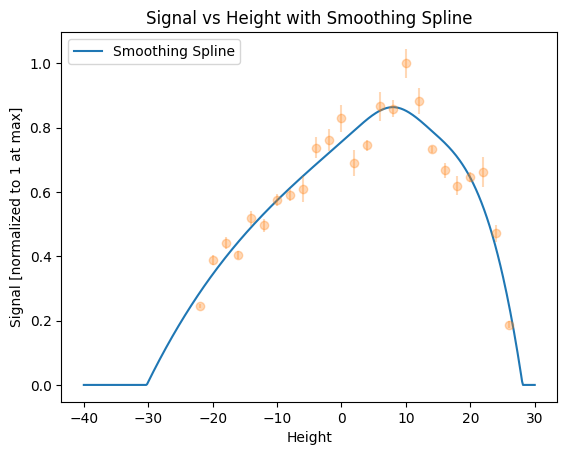

In [19]:
from scipy.interpolate import UnivariateSpline

# Weights (w) can be 1/error_bar to tell the spline which points to trust more
# If you have errors: weights = 1.0 / np.array([v.std_dev for v in ...])
x = np.array(list(signal_vs_height_short[0.0].keys())) - 23
y = np.array([v.n for v in signal_vs_height_short[0.0].values()])

# Create a smoothing spline
# s is the smoothing parameter; adjust it until it looks right!
signal_vs_height_short_interp = UnivariateSpline(x, y/np.max(y), s=0.1) 

x_new = np.linspace(-40, 30, 500)
y_new = np.maximum(signal_vs_height_short_interp(x_new), 0)  # Ensure no negative values
plt.plot(x_new, y_new, label='Smoothing Spline')
plt.errorbar(x, y/np.max(y), yerr=[v.s for v in signal_vs_height_short[0.0].values()]/np.max(y), fmt='o', alpha=0.3)
plt.legend()
plt.xlabel('Height')
plt.ylabel('Signal [normalized to 1 at max]')
plt.title('Signal vs Height with Smoothing Spline')

In [20]:

# EQL parameters
L = 0.6
R = 1.75 * 25.4e-3 / 2
V = 28_000


# [NEW] don't limit DET aperture size, do post selection later
wx = 0.1
wy = 0.1

# conversion factors
in_to_m = 25.4e-3

n_nipples = 3

# beamline lengths
distance_lens_bbexit = 36 * in_to_m
lens_chamber_length = (24 + 5 / 8) * in_to_m
lens_reducer_flange = (7 / 8 + 3 + 1 / 8) * in_to_m
lens_electrode_length = L  # m
nipple_length = 39 * in_to_m
distance_det_center = 5.25 * in_to_m
lens_reducer_flange = (3 + 1 / 8 + 7 / 8) * in_to_m
bs_flange = 3 / 4 * in_to_m
rc_chamber_length_no_flanges = 10.5 * in_to_m
rc_chamber_center_from_bs_front = (16 + 3 / 8) * in_to_m
rc_aperture_from_center = 3.56 * in_to_m
rc_aperture_radius = 0.011

In [21]:
MEASURED_RES_PARAMS = [ 0.4056197,  -0.35732858,  2.2139628,   0.06165752]
amplitude = MEASURED_RES_PARAMS[0]
SIGMA = MEASURED_RES_PARAMS[2]*1e-3
OFFSET = MEASURED_RES_PARAMS[3]
R_MAX=10e-3

rs = np.linspace(0, R_MAX, 1000)
F_r = amplitude * np.exp(-(rs**2) / (2 * SIGMA**2)) + OFFSET

# 4. CRITICAL STEP: Apply the Jacobian radial weight (2 * pi * r)
# This prevents the center from overcrowding and accounts for the ring area
R_r = 2 * np.pi * rs * F_r

# 5. Normalize into a Cumulative Distribution Function (CDF)
pdf_r = R_r / np.trapz(R_r, rs)
cdf_r = np.cumsum(pdf_r)
cdf_r /= cdf_r[-1]  # Force the array to end exactly at 1.0

# 6. Transfer the lookup tables to the GPU
cp_cdf_r = cp.array(cdf_r)
cp_rs = cp.array(rs)

def position_init(n_trajectories):
    # 7. Generate uniform random numbers for Radius and Angle
    u_r = cp.random.rand(n_trajectories)
    u_theta = cp.random.rand(n_trajectories) * 2 * cp.pi

    # 8. Sample the Radius and convert to Cartesian
    sampled_r = cp.interp(u_r, cp_cdf_r, cp_rs)
    sampled_x = sampled_r * cp.cos(u_theta)
    sampled_y = sampled_r * cp.sin(u_theta)

    # (Optional) Initialize your Coordinates object here
    return Coordinates(sampled_x, sampled_y, cp.zeros(n_trajectories))

C:\Users\zhoup\AppData\Local\Temp\ipykernel_47772\1745079868.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_r = R_r / np.trapz(R_r, rs)


In [22]:
# signal_vs_height_short_interp = None
class Interpolator3DWrapper:
    def __init__(self, interp2d):
        self.interp2d = interp2d
    def __call__(self, vz, y0, vx):
        # ignore vz for interpolation; support scalar or array y0/vx
        y0_a = np.asarray(y0)
        vx_a = np.asarray(vx)
        y0_b, vx_b = np.broadcast_arrays(y0_a, vx_a)
        pts = np.column_stack((y0_b.ravel(), vx_b.ravel()))
        res = self.interp2d(pts)
        return np.array(res).reshape(y0_b.shape)
    
ROOT_DIR = Path("saved_trajectories_from_measured_initial_dist")
HEIGHT_SCANS = np.unique(
    np.concatenate([
        np.arange(-25, 27, 2) * 1e-3, 
        np.arange(-10, 11, 1) * 1e-3,
    ])
)
DELTA_SIGMA = 2e-4
MAX_TRAJECTORIES_PER_SIMULATION = int(5e6) #int(5e6) # limited by VRAM
INTERPOLATOR = pickle.load(open("3d_interpolator.pkl", "rb"))
# (cp_xs_interp, cp_cdf) = pickle.load(open("interp_origin.pkl", "rb"))



all_tasks = []
saved_trajectories_before_lens = {}
saved_0kV_data = {}
def find_close_idx(key1, key2, key3, data_dict, delta_key1=None, delta_key2=None, delta_key3=None):
    def _find_match(target, current_dict, delta=None):
        # Use next() with a generator expression to find the first key that is numerically close.
        # Returns the actual key (k) or None if the generator is exhausted.
        if delta is None:
            delta = 1e-6
        return next((k for k in current_dict.keys() if np.isclose(k, target, atol=delta)), None)
    k1 = _find_match(key1, data_dict, delta_key1)
    if k1 is None:
        # print(f"Match not found for key1 ({key1})")
        return None
    k2 = _find_match(key2, data_dict[k1], delta_key2)
    if k2 is None:
        return None
    k3 = _find_match(key3, data_dict[k1][k2], delta_key3)
    if k3 is None:
        return None
    return (k1, k2, k3)

def find_and_load_trajectories(ROOT_DIR, sigma, n_trajectories, vz_mean, vz_sigma, tolerance=DELTA_SIGMA):
    return None

def generate_or_read_dist_before_lens(sigma, vz_mean, vz_sigma, n_trajectories):
    global saved_trajectories_before_lens
    idxs = find_close_idx(sigma, vz_mean, vz_sigma, saved_trajectories_before_lens, delta_key3=1e-5)
    if idxs is not None:
        sigma, vz_mean, vz_sigma = idxs
        return saved_trajectories_before_lens[sigma][vz_mean][vz_sigma]
    # velocities = Velocities(
    #             vx=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * 40 + vz_mean * 0.1,
    #             vy=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * 40 - vz_mean * 0.1,
    #             vz=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * vz_sigma + vz_mean
    #         )
    velocities = Velocities(
        vx=cp.random.randn(n_trajectories) * 39.4,
        vy=cp.random.randn(n_trajectories) * 39.4,
        vz=generate_vz_distribution(n_trajectories, vz_mean=vz_mean, vz_sigma=vz_sigma)
    )
    # velocities = Velocities(
    #     vx=cp.random.uniform(-10, 10, n_trajectories),
    #     vy=cp.random.uniform(-10, 10, n_trajectories),
    #     vz=generate_vz_distribution(n_trajectories, vz_mean=vz_mean, vz_sigma=vz_sigma)
    # )
    # origin = Coordinates(
    #     x=1e-3 * cp.random.randn(n_trajectories),
    #     y=1e-3 * cp.random.randn(n_trajectories),
    #     z=cp.zeros(n_trajectories),
    # )
    if sigma == 2.2e-3:
        origin = position_init(n_trajectories)
    else:
        origin = Coordinates(
            x=sigma * cp.random.randn(n_trajectories),
            y=sigma * cp.random.randn(n_trajectories),
            z=cp.zeros(n_trajectories),
        )
    propagated_origin, propagated_velocities = generate_dist_before_lens(origin, velocities)
    saved_trajectories_before_lens.setdefault(sigma, {}).setdefault(vz_mean, {})[vz_sigma] = (propagated_origin, propagated_velocities)
    # gc.collect()
    return propagated_origin, propagated_velocities

def generate_or_read_0kV_data(sigma, vz_mean, vz_sigma, n_trajectories, aperture: bool = True, signal_vs_height_short_interp=signal_vs_height_short_interp):
    global saved_0kV_data
    idxs = find_close_idx(sigma, vz_mean, vz_sigma, saved_0kV_data, delta_key3=DELTA_SIGMA)
    if idxs is not None:
        sigma, vz_mean, vz_sigma = idxs
        if aperture in saved_0kV_data[sigma][vz_mean][vz_sigma]:
            return saved_0kV_data[sigma][vz_mean][vz_sigma][aperture]
    
    saved_data = find_and_load_trajectories(ROOT_DIR, sigma, n_trajectories, vz_mean, vz_sigma, tolerance=DELTA_SIGMA)
    if saved_data is not None:
        logging.info("Loaded existing 0kV data from file")
        saved_trajectories = saved_data
    else:
        nr_simulations = int(n_trajectories // MAX_TRAJECTORIES_PER_SIMULATION)
        logging.info(f"Number of simulations for 0kV: {nr_simulations}")
        saved_trajectories = Trajectories()
        for _ in range(nr_simulations):
            # velocities = Velocities(
            #     vx=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * 40 + vz_mean * 0.1,
            #     vy=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * 40 - vz_mean * 0.1,
            #     vz=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * vz_sigma + vz_mean
            # )
            velocities = Velocities(
                vx=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * 39.4,
                vy=cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION) * 39.4,
                vz=generate_vz_distribution(MAX_TRAJECTORIES_PER_SIMULATION, vz_mean=vz_mean, vz_sigma=vz_sigma)
            )
            # velocities = Velocities(
            #     vx=cp.random.uniform(-10, 10, MAX_TRAJECTORIES_PER_SIMULATION),
            #     vy=cp.random.uniform(-10, 10, MAX_TRAJECTORIES_PER_SIMULATION),
            #     vz=generate_vz_distribution(MAX_TRAJECTORIES_PER_SIMULATION, vz_mean=vz_mean, vz_sigma=vz_sigma)
            # )
            if sigma == 2.2e-3:
                origin = position_init(MAX_TRAJECTORIES_PER_SIMULATION)
            else:
                origin = Coordinates(
                    x=sigma * cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION),
                    y=sigma * cp.random.randn(MAX_TRAJECTORIES_PER_SIMULATION),
                    z=cp.zeros(MAX_TRAJECTORIES_PER_SIMULATION),
                )
            logging.info(f"Finished 0kV origin nr_trajectories: {MAX_TRAJECTORIES_PER_SIMULATION:.0e}")
            _, _trajectories, _ = lens_scan_function_0kV(origin, velocities, include_det_short=False)
            saved_trajectories.merge_and_reindex(_trajectories) 
            logging.info(f"Finished 0kV simulation nr_trajectories: {MAX_TRAJECTORIES_PER_SIMULATION:.0e}")
        mempool = cp.get_default_memory_pool()
        mempool.free_all_blocks() # Give the 20 GB block back to the OS
        logging.info("freed cupy memory pool")
    saved_0kV_data.setdefault(sigma, {}).setdefault(vz_mean, {}).setdefault(vz_sigma, {})[aperture] = process_single_trajectories_parallel(saved_trajectories, INTERPOLATOR, HEIGHT_SCANS, nr_trajectories=n_trajectories, aperture=aperture, det_short_interpolator=signal_vs_height_short_interp)
    logging.info("started gc collect")
    gc.collect()
    logging.info("finished gc collect")
    return saved_0kV_data[sigma][vz_mean][vz_sigma][aperture]

def trajectory_simulations(vz_mean, vz_sigma, sigma, offset, tilt, n_trajectories = MAX_TRAJECTORIES_PER_SIMULATION, dataset='dataset_1', signal_vs_height_short_interp=signal_vs_height_short_interp):     
    voltages = np.array([0, 20, 22.5, 26.25, 30]) * 1e3
    scan_results = {}
    for voltage in voltages:
        if voltage == 0:
            logging.info("Processing 0kV data")
            scan_results[voltage] = generate_or_read_0kV_data(sigma, vz_mean, vz_sigma, n_trajectories*10, aperture=True)
        else:
            logging.info(f"Processing {voltage/1e3}kV data")
            propagated_origin, propagated_velocities = generate_or_read_dist_before_lens(sigma, vz_mean, vz_sigma, n_trajectories)
            logging.info(f"Starting lens scan function for {voltage/1e3}kV")
            _v1, _trajectories, _v2 = lens_scan_function_with_input_before_lens(
                propagated_origin,
                propagated_velocities,
                voltage,
                tilt=tilt,
                y_offset=offset,
                include_det_short=False
            )
            scan_results[voltage] = process_single_trajectories_parallel(_trajectories, INTERPOLATOR, HEIGHT_SCANS, nr_trajectories=n_trajectories, aperture=True, det_short_interpolator=signal_vs_height_short_interp)
    return scan_results


C:\Users\zhoup\AppData\Local\Temp\ipykernel_47772\2929689767.py:23: DeprecationWarning: Please import `LinearNDInterpolator` from the `scipy.interpolate` namespace; the `scipy.interpolate.interpnd` namespace is deprecated and will be removed in SciPy 2.0.0.
  INTERPOLATOR = pickle.load(open("3d_interpolator.pkl", "rb"))


In [44]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
from uncertainties import unumpy
from scipy.optimize import minimize
# trial_results = {}
if 'trial_results' not in globals():
    trial_results = {}
if 'trial_results_tilt' not in globals():
    trial_results_tilt = {} 
dataset = 'dataset_4'
# sigma = 6e-3
offset = 0
tilt = 1e-3
for sigma in np.array([2.2e-3]):
    for vz_mean in [187, 182, 192]:
        scan_results = trajectory_simulations(vz_mean, 17, sigma, offset, tilt, dataset=dataset)
        # trial_results.setdefault(vz_mean, {})[sigma] = scan_results
        trial_results_tilt.setdefault(vz_mean, {}).setdefault(tilt, {})[sigma] = scan_results

2026-03-23 11:47:49,865 - INFO - Processing 0kV data
2026-03-23 11:47:49,866 - INFO - Processing 20.0kV data
2026-03-23 11:47:49,866 - INFO - Starting lens scan function for 20.0kV
2026-03-23 11:47:55,128 - INFO - Processing 22.5kV data
2026-03-23 11:47:55,129 - INFO - Starting lens scan function for 22.5kV
2026-03-23 11:47:59,764 - INFO - Processing 26.25kV data
2026-03-23 11:47:59,765 - INFO - Starting lens scan function for 26.25kV
2026-03-23 11:48:05,924 - INFO - Processing 30.0kV data
2026-03-23 11:48:05,925 - INFO - Starting lens scan function for 30.0kV
2026-03-23 11:48:12,281 - INFO - Processing 0kV data
2026-03-23 11:48:12,282 - INFO - Processing 20.0kV data
2026-03-23 11:48:12,283 - INFO - Starting lens scan function for 20.0kV
2026-03-23 11:48:18,303 - INFO - Processing 22.5kV data
2026-03-23 11:48:18,304 - INFO - Starting lens scan function for 22.5kV
2026-03-23 11:48:24,320 - INFO - Processing 26.25kV data
2026-03-23 11:48:24,321 - INFO - Starting lens scan function for 26

In [45]:
cp.get_default_memory_pool().free_all_blocks()

In [46]:
from uncertainties import unumpy
def plot_simulation(signal_vs_height, signal_vs_height_top, signal_vs_height_bottom, multiple_simulations, h0 = 25, annotation='', plot_experiment=True):
    fig, axs = plt.subplots(1, 5, figsize=(48, 5))
    fig.subplots_adjust(wspace=0.2, hspace=0.2)
    
    for simulations in multiple_simulations:
        def fit_func(scale, hv_voltage=0):
            global interp_values
            err = 0
            _s_keys = np.array(list(signal_vs_height[hv_voltage].keys())) - h0
            _simulation_keys = np.array(list(simulations[hv_voltage*1000].keys()))*1000
            _simulation_values = np.array([sv.n for sv in simulations[hv_voltage*1000].values()])
            _simulation_errors = np.array([sv.s for sv in simulations[hv_voltage*1000].values()])
            interp_values = np.interp(_s_keys, _simulation_keys, _simulation_values)
            interp_errors = np.interp(_s_keys, _simulation_keys, _simulation_errors)
            mask = abs(np.array(_s_keys))<10
            # err = np.sum( (unumpy.nominal_values(np.array(list(signal_vs_height[0].values()))) - interp_values/scale)**2 / (unumpy.std_devs(np.array(list(signal_vs_height[0].values())))**2 + (interp_errors/scale)**2) )
            err = np.sum( ((unumpy.nominal_values(np.array(list(signal_vs_height[hv_voltage].values()))) - interp_values/scale)**2)[mask])
            return err
        _scale = minimize(fit_func,4e-5).x[0]

        # print(f"Using scale factor: {_scale}")
        chi2 = 0
        for hv_voltage, signal in signal_vs_height.items():
            try:
                height = np.array(list(signal.keys()))
                signal = np.array(list(signal.values()))
                simulation_val = np.array([sv.n for sv in simulations[hv_voltage*1000].values()])
                simulation_errors = np.array([sv.s for sv in simulations[hv_voltage*1000].values()])
                height_simu = np.fromiter(simulations[hv_voltage*1000].keys(), dtype=np.float64)
                height_simu = height_simu*1000
                simulation_interp = np.interp(height-h0, height_simu, simulation_val)
                simulation_error_interp = np.interp(height-h0, height_simu, simulation_errors)
                chi2 += np.sum( (unumpy.nominal_values(signal) - simulation_interp/_scale)**2 / (unumpy.std_devs(signal)**2 + (simulation_error_interp/_scale)**2 ))
            except KeyError:
                continue
        chi2_ndf = chi2 / (len(signal_vs_height[0])*len(signal_vs_height))
        # if chi2_ndf > 269 and chi2_ndf < 271:
        #     raise KeyboardInterrupt
        # print(f"{annotation}: Chi2 / ndf = {chi2_ndf:.2f} ")
        if True:
            annotation += f' Chi2/ndf={chi2_ndf:.2f}'
            
            i = 0
            for hv_voltage, signal in signal_vs_height.items():
                if hv_voltage == 0.0:
                    scale = _scale
                else:
                    scale = _scale
                ax = axs[i]
                
                height = np.array(list(signal.keys()))
                signal = np.array(list(signal.values()))
                try:
                    # print(f"Plotting {hv_voltage} kV")
                    simulations[hv_voltage*1000]
                    if plot_experiment:
                        ax.errorbar(
                            height-h0, unumpy.nominal_values(signal), yerr=unumpy.std_devs(signal),
                            fmt="o", label=f"PMT"
                        )
                        if signal_vs_height_top:
                            # Plot signal vs height (top)
                            signal_top = np.array(list(signal_vs_height_top[hv_voltage].values()))
                            ax.errorbar(
                                height-h0, unumpy.nominal_values(signal_top), yerr=unumpy.std_devs(signal_top),
                                fmt="o", label=f"PMT (Top)"
                            )

                        # Plot signal vs height (bottom)
                        if signal_vs_height_bottom:
                            signal_bottom = np.array(list(signal_vs_height_bottom[hv_voltage].values()))
                            ax.errorbar(
                                height-h0, unumpy.nominal_values(signal_bottom), yerr=unumpy.std_devs(signal_bottom),
                                fmt="o", label=f"PMT (Bottom)"
                            )
                        
                    height = np.fromiter(simulations[hv_voltage*1000].keys(), dtype=np.float64)
                    sorted_height = height*1000
                    sorted_simulation_val = np.array([sv.n for sv in simulations[hv_voltage*1000].values()])
                    sorted_simulation_err = np.array([sv.s for sv in simulations[hv_voltage*1000].values()])
                    ax.fill_between(
                        sorted_height, 
                        (sorted_simulation_val + sorted_simulation_err) / scale, 
                        (sorted_simulation_val - sorted_simulation_err) / scale, 
                        alpha=0.8, 
                        label=f"Simulation", 
                        color='orange'
                    )
                    i += 1
                    ax.grid()
                    ax.set_ylim(0, None)
                    ax.text(0.2, 0.95, f'{hv_voltage} kV', transform=ax.transAxes, fontsize=25, ha='center', va='top', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5'))
                    ax.legend(loc='lower left')
                    ax.set_xlabel("Laser height (mm)", fontsize=25)
                    ax.set_ylabel("Signal Normalized (a.u.)", fontsize=25)
                    ax.tick_params(axis='both', which='major', labelsize=25)
                except KeyError:
                    continue
                fig.text(
                    0.2, 0.2, 
                    # "",
                    annotation, 
                    # "lens tilt up by 3mm",
                    fontsize=30, 
                    ha='left', 
                    va='bottom', 
                    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5')
                )
        plot_experiment = False

In [47]:
def generate_annotation(key, sigma, offset, tilt):
    # sigma = sigma 
    # offset = offset + experimental_conditions[key]['delta_offset']
    # tilt = tilt + experimental_conditions[key]['delta_tilt']
    return f"key={key} initial σ={int(float(sigma)*1000)}mm lens tilt {int(float(tilt)*1000)}e-3 rad, shift {int(float(offset)*1000)}mm"

def get_dict_result(d, sigma, offset, tilt):
    def find_close_key(dictionary, target_value, tolerance=1e-6):
        """
        Finds the key in a dictionary that is closest to the target_value
        within a specified tolerance.
        """
        for key in dictionary:
            # Check if the key is numerically close to the target value
            if np.isclose(key, target_value, atol=tolerance):
                return key
        return None # Return None if no close key is found

    # Your target keys
    target_key1 = sigma
    target_key2 = offset
    target_key3 = tilt

    # --- Step 1: Find the actual first key ---
    actual_key1 = find_close_key(trial_results, target_key1)

    if actual_key1 is not None:
        # --- Step 2: Access the next level and find the actual second key ---
        actual_key2 = find_close_key(trial_results[actual_key1], target_key2)

        if actual_key2 is not None:
            # --- Step 3: Access the third level and find the actual third key ---
            actual_key3 = find_close_key(trial_results[actual_key1][actual_key2], target_key3)

            if actual_key3 is not None:
                # --- Final Access ---
                result = trial_results[actual_key1][actual_key2][actual_key3]
                # print(f"Successfully retrieved result using keys: {actual_key1}, {actual_key2}, {actual_key3}")
                return result
            else:
                print(f"Key 3 ({target_key3}) not found in the third-level dictionary.")
        else:
            print(f"Key 2 ({target_key2}) not found in the second-level dictionary.")
    else:
        print(f"Key 1 ({target_key1}) not found in the top-level dictionary.")

In [ ]:
import pickle
# with open("trial_results.pkl", "wb") as f:
#     pickle.dump(trial_results, f)
# with open("trial_results.pkl", "rb") as f:
#     loaded_results = pickle.load(f)
# trial_results = loaded_results

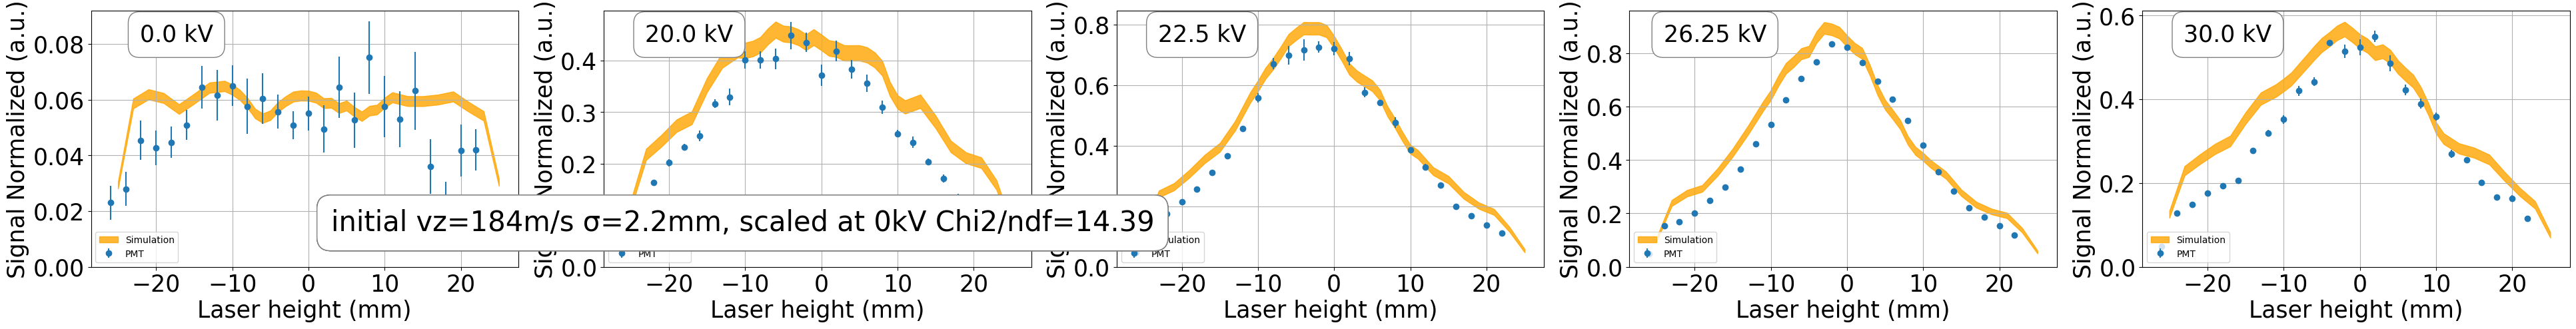

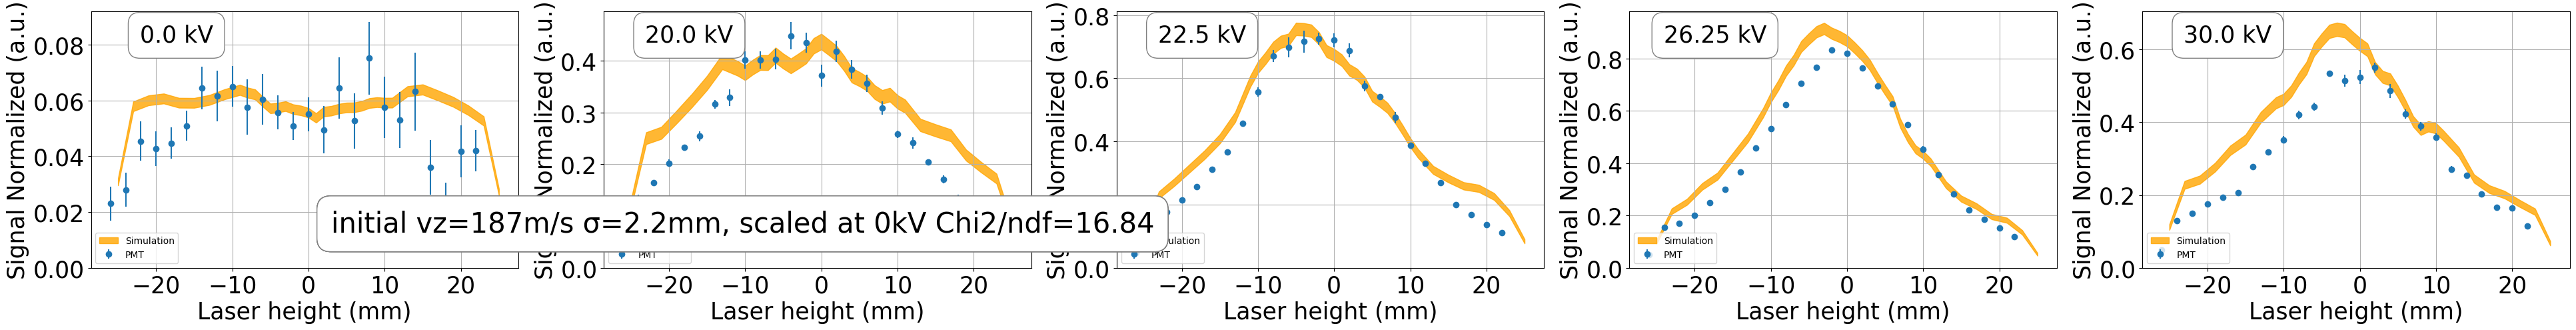

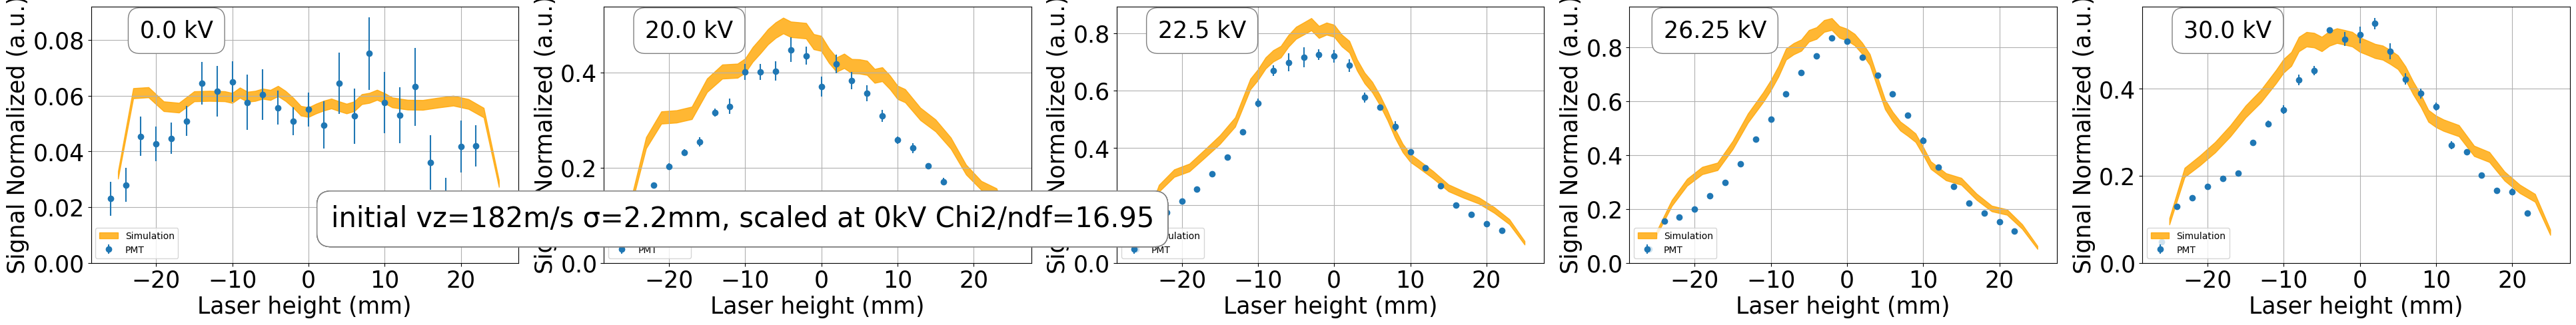

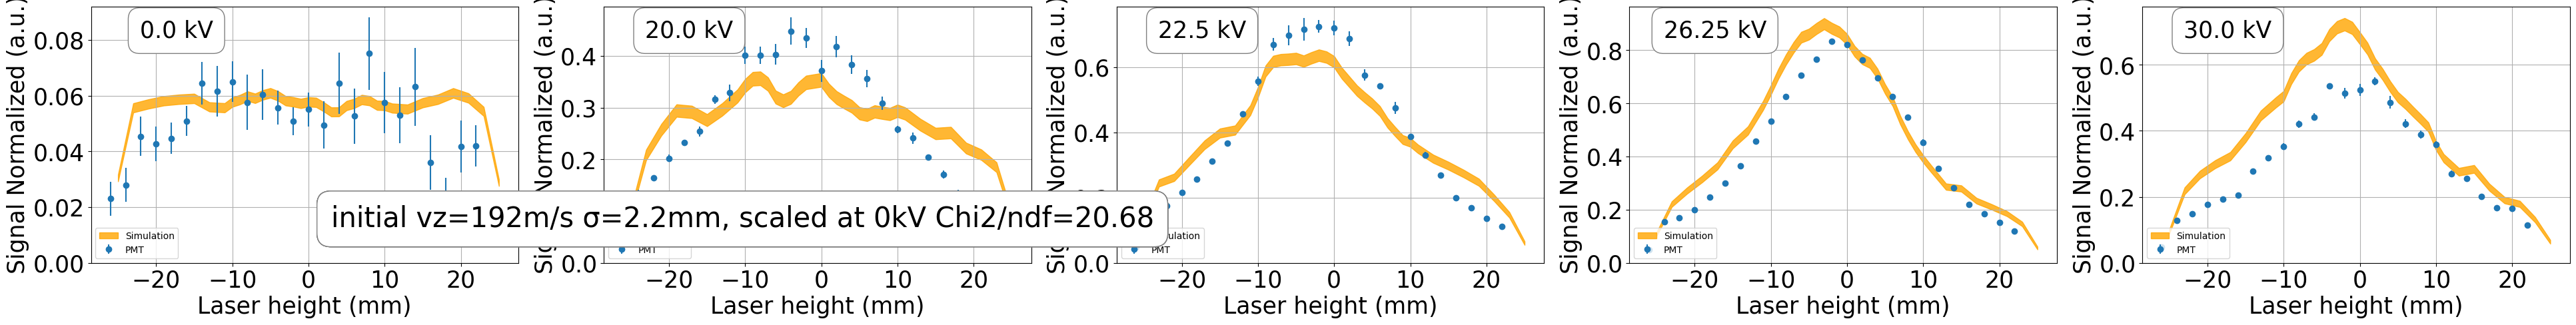

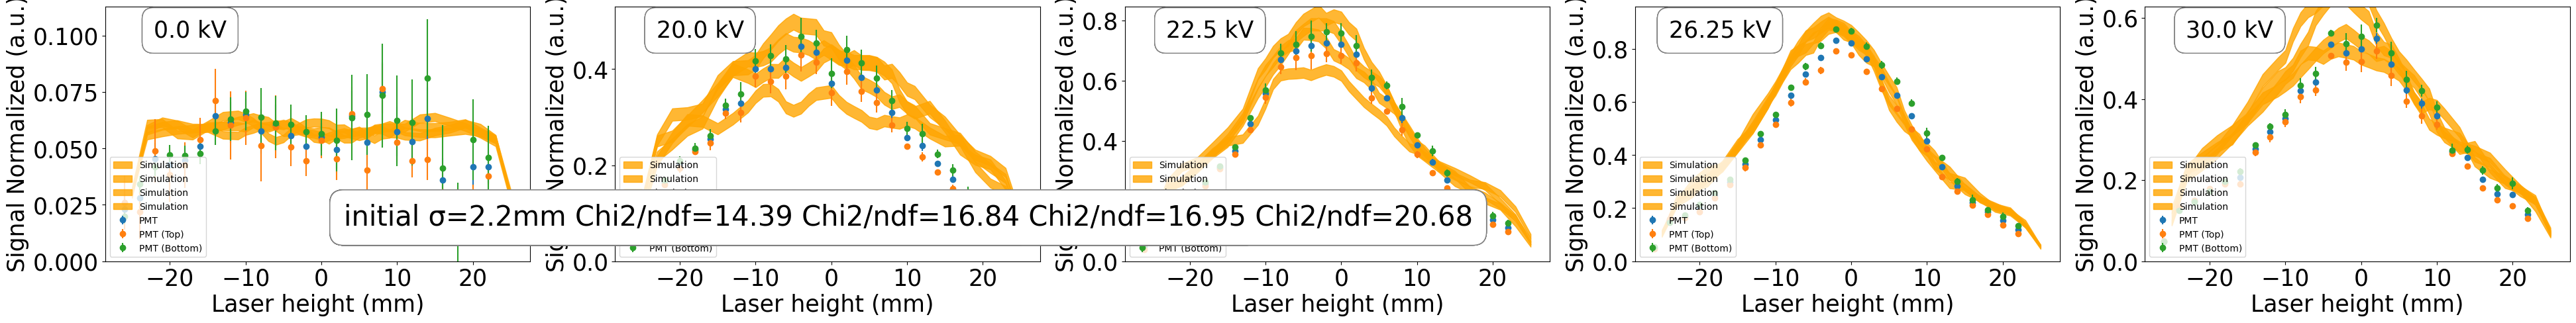

In [43]:
from matplotlib import pyplot as plt
from scipy.optimize import minimize
import numpy as np
all_final_results = []
for _v in trial_results.keys():
    if True:
        result = trial_results[_v]
        for sigma, final_result in result.items():
            if final_result:
                # signal_vs_height = scan_lens_data
                # signal_vs_height_top = scan_lens_data
                # signal_vs_height_bottom = scan_lens_data
                # signal_vs_height = data_from_measurements['dataset_4']['signal_vs_height']
                # signal_vs_height_top = data_from_measurements['dataset_4']['signal_vs_height_top']
                # signal_vs_height_bottom = data_from_measurements['dataset_4']['signal_vs_height_bottom']
                plot_simulation(signal_vs_height, None, None, [final_result], annotation=f'initial vz={_v}m/s σ={(float(sigma)*1000):.1f}mm, scaled at 0kV', h0=27, plot_experiment=True)

                all_final_results.append(final_result)
plot_simulation(signal_vs_height, signal_vs_height_top, signal_vs_height_bottom, all_final_results, annotation=f'initial σ={(float(sigma)*1000):.1f}mm', h0=27, plot_experiment=True)

In [50]:
trial_results_tilt[_v][0.001].keys()

dict_keys([np.float64(0.0022)])

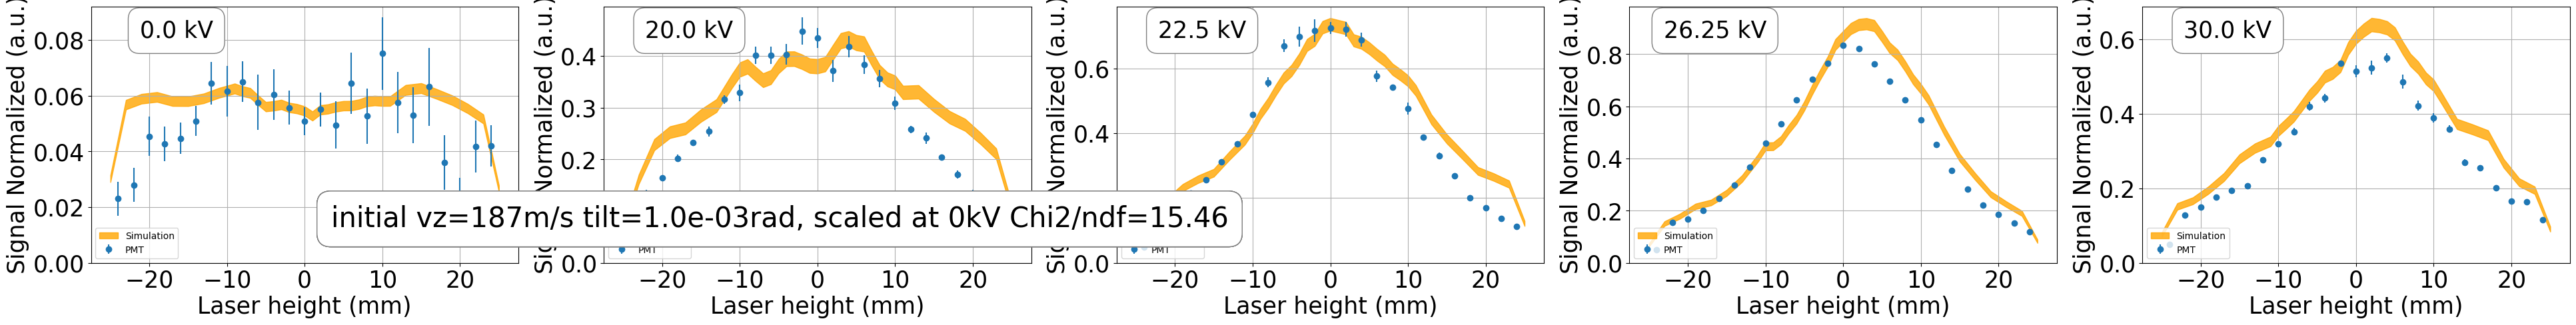

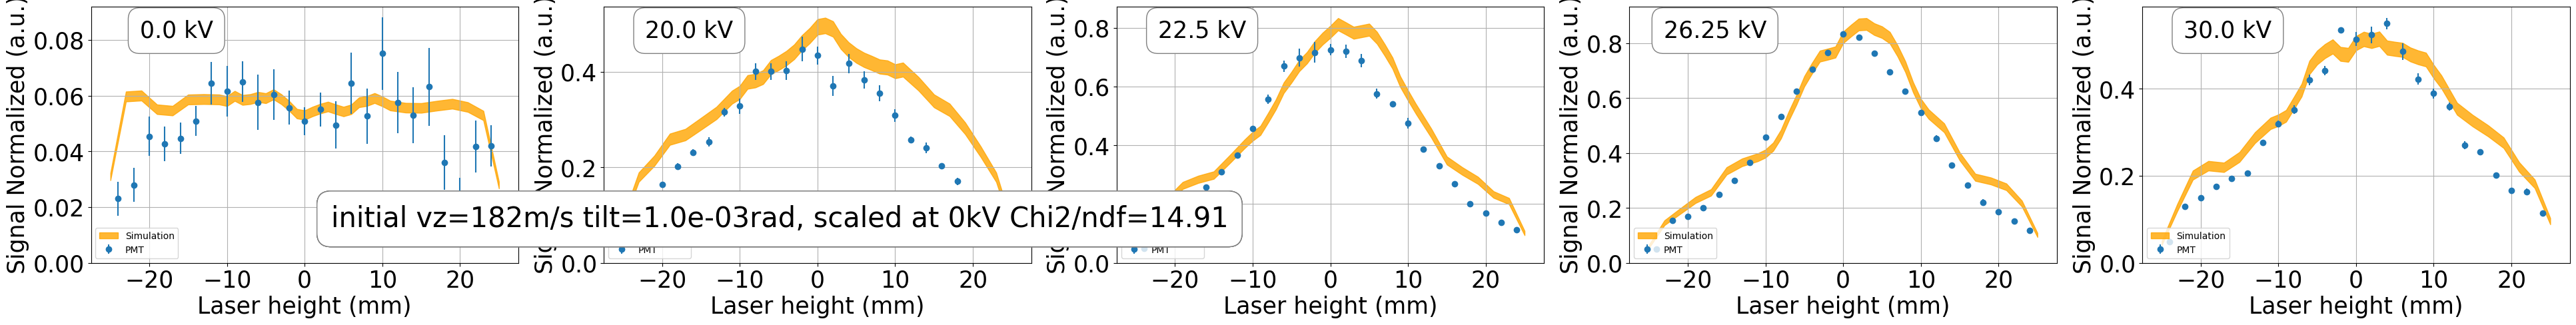

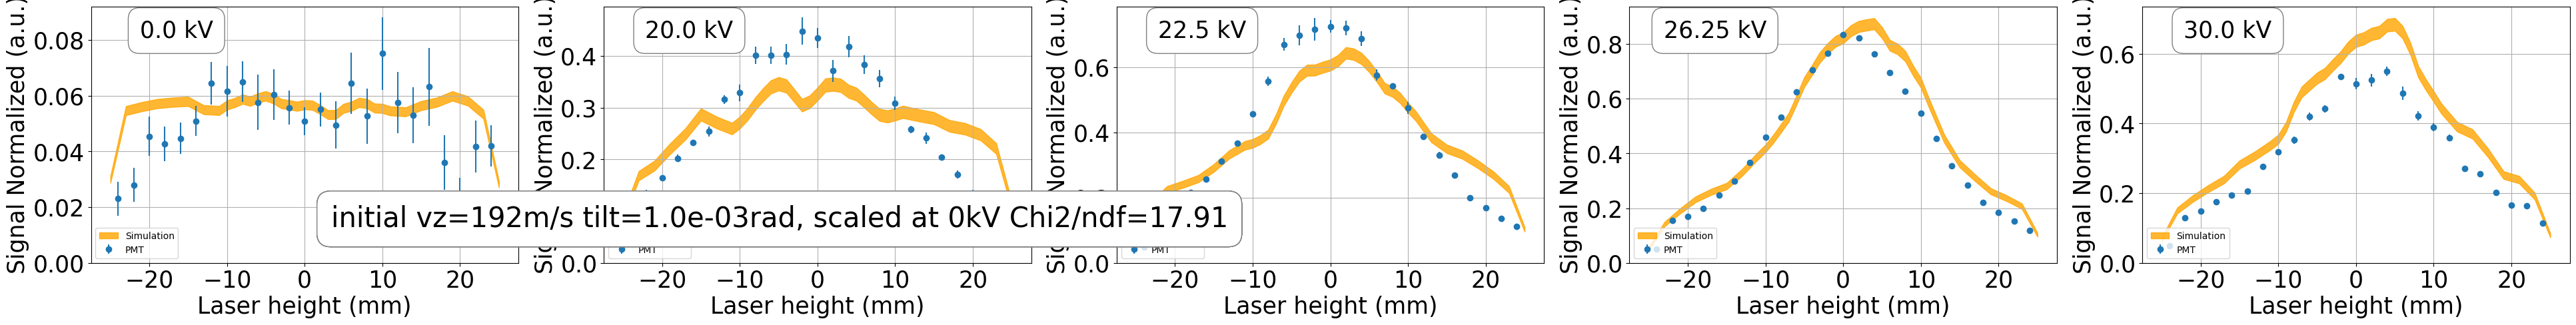

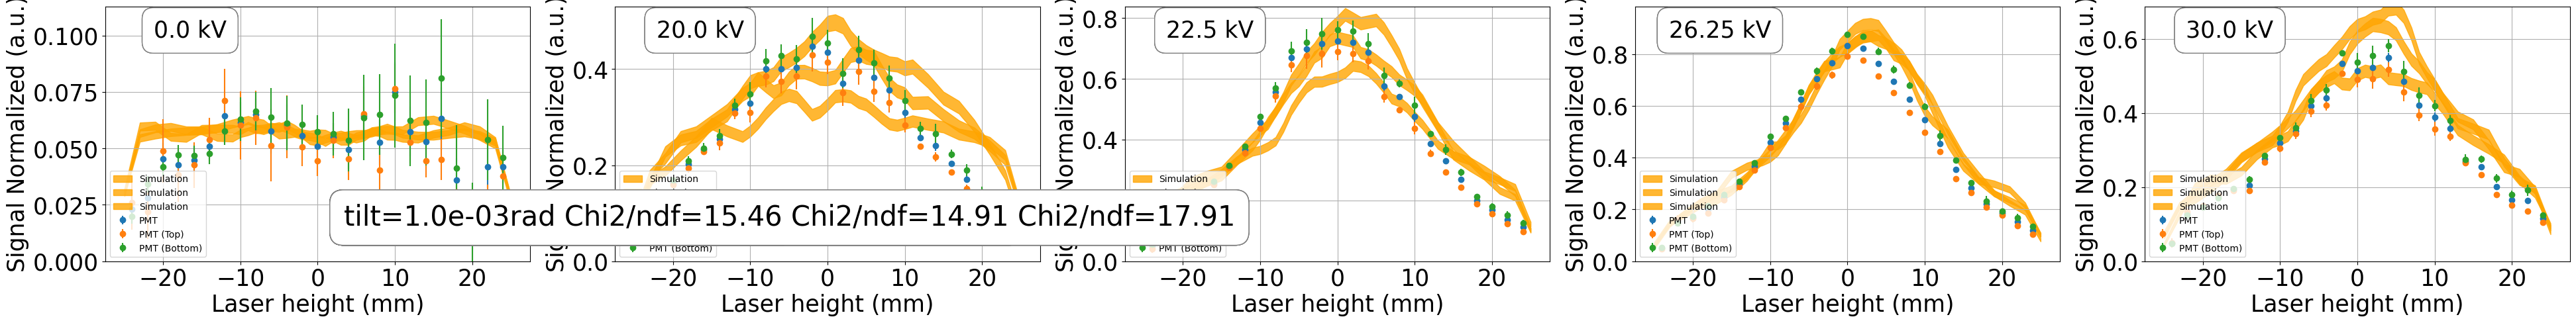

In [52]:

from scipy.optimize import minimize
import numpy as np
all_final_results = []
for _v in trial_results_tilt.keys():
    if True:
        result = trial_results_tilt[_v]
        for tilt, final_result in result.items():
            if final_result:
                final_result = final_result[2.2e-3]
                # signal_vs_height = scan_lens_data
                # signal_vs_height_top = scan_lens_data
                # signal_vs_height_bottom = scan_lens_data
                # signal_vs_height = data_from_measurements['dataset_4']['signal_vs_height']
                # signal_vs_height_top = data_from_measurements['dataset_4']['signal_vs_height_top']
                # signal_vs_height_bottom = data_from_measurements['dataset_4']['signal_vs_height_bottom']
                plot_simulation(signal_vs_height, None, None, [final_result], annotation=f'initial vz={_v}m/s tilt={(float(tilt)):.1e}rad, scaled at 0kV', h0=25, plot_experiment=True)

                all_final_results.append(final_result)
plot_simulation(signal_vs_height, signal_vs_height_top, signal_vs_height_bottom, all_final_results, annotation=f'tilt={(float(tilt)):.1e}rad', h0=25, plot_experiment=True)

In [29]:
def plot_gain(signal_vs_height, signal_vs_height_top, signal_vs_height_bottom, all_simulation, h0=23, annotation=''):
    fig, axs = plt.subplots(1, 5, figsize=(48, 5))
    fig.subplots_adjust(wspace=0.2, hspace=0.2)
    flag = False
    for simulation in all_simulation:
        i = 0
        chi2 = 0
        for hv_voltage, signal in signal_vs_height.items():
            height = np.array(list(signal.keys()))
            gain = np.array(list(signal.values()))/np.array(list(signal_vs_height[0.0].values()))

            simulation_val_with_error = np.array([sv for sv in simulation[hv_voltage*1000].values()])
            simulation_0kV_with_error = np.array([sv for sv in simulation[0.0].values()])

            simulation_gain_val = np.array([v.n for v in (simulation_val_with_error / simulation_0kV_with_error)])
            simulation_gain_err = np.array([v.s for v in (simulation_val_with_error / simulation_0kV_with_error)])
            height_simu = np.fromiter(simulation[hv_voltage*1000].keys(), dtype=np.float64)
            height_simu = height_simu*1000
            
            simulation_interp = np.interp(height-h0, height_simu, simulation_gain_val)
            simulation_gain_err_interp = np.interp(height-h0, height_simu, simulation_gain_err)
            if hv_voltage == 0.0:
                continue    
            chi2 += np.sum( (unumpy.nominal_values(gain) - simulation_interp)**2 / (unumpy.std_devs(gain)**2 + (simulation_gain_err_interp)**2) )
        chi2_ndf = chi2 / (len(signal_vs_height[0])*(len(signal_vs_height)-1))
        if chi2_ndf < 20:

            annotation += f' Chi2/ndf={chi2_ndf:.2f}'
            for hv_voltage, signal in signal_vs_height.items():
                try:
                    ax = axs[i]
                    if hv_voltage == 0.0:
                        ax.set_ylim(0, 2)
                    i += 1
                    height = np.array(list(signal.keys()))
                    gain = np.array(list(signal.values()))/np.array(list(signal_vs_height[0.0].values()))
                    if not flag:
                        ax.errorbar(
                            height-h0, unumpy.nominal_values(gain), yerr=unumpy.std_devs(gain),
                            fmt="o", label=f"PMT"
                        )
                    # Plot signal vs height (top)
                    # gains = np.array(list(signal_vs_height_top[hv_voltage].values()))/np.array(list(signal_vs_height_top[0.0].values()))
                # ax.errorbar(
                #     height-h0, unumpy.nominal_values(gains), yerr=unumpy.std_devs(gains),
                #     fmt="o", label=f"PMT (Top)"
                # )

                # # Plot signal vs height (bottom)
                # gains_bottom = np.array(list(signal_vs_height_bottom[hv_voltage].values()))/np.array(list(signal_vs_height_bottom[0.0].values()))
                # ax.errorbar(
                #     height-h0, unumpy.nominal_values(gains_bottom), yerr=unumpy.std_devs(gains_bottom),
                #     fmt="o", label=f"PMT (Bottom)"
                # )

                    height = np.fromiter(simulation[hv_voltage*1000].keys(), dtype=np.float64)*1000

                    
                    simulation_val_with_error = np.array([sv for sv in simulation[hv_voltage*1000].values()])
                    simulation_0kV_with_error = np.array([sv for sv in simulation[0.0].values()])
            
                    simulation_gain_val = np.array([v.n for v in (simulation_val_with_error / simulation_0kV_with_error)])
                    simulation_gain_err = np.array([v.s for v in (simulation_val_with_error / simulation_0kV_with_error)])

                    sorted_simulation_gain_val = simulation_gain_val
                    sorted_simulation_gain_err = simulation_gain_err
                    ax.fill_between(
                        height,
                        (sorted_simulation_gain_val + sorted_simulation_gain_err),
                        (sorted_simulation_gain_val - sorted_simulation_gain_err),
                        alpha=0.8,
                        label=f"Simulation {hv_voltage}kV", 
                        color='orange'
                    )
                    ax.grid(True)
                    ax.set_title(f'{hv_voltage} kV')
                    ax.legend(loc='lower left')
                    ax.set_xlabel("Laser height (mm)")
                    ax.set_ylabel("Gain (a.u.)")
                    ax.set_xlim(-25,25)

                except Exception as e:
                    print(f"Skipping {hv_voltage} kV due to error: {e}")
                    continue
            fig.text(
                0.2, 0.2, 
                annotation, 
                # "lens tilt up by 3mm",
                fontsize=30, 
                ha='left', 
                va='bottom', 
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5')
            )
            flag = True

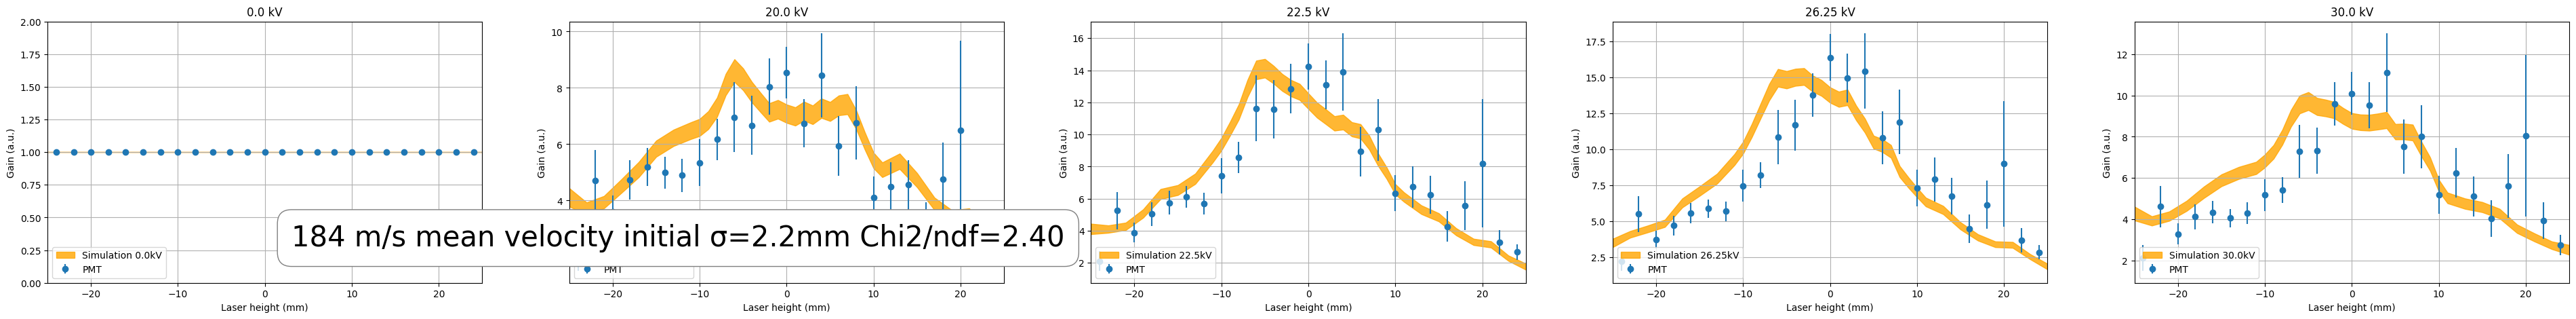

In [30]:
for _v in trial_results.keys():
    result = trial_results[_v]
    for sigma, final_result in result.items():
        if final_result:
            plot_gain(signal_vs_height, signal_vs_height_top, signal_vs_height_bottom, [final_result], annotation=f'{_v} m/s mean velocity initial σ={(float(sigma)*1000):.1f}mm', h0=25)


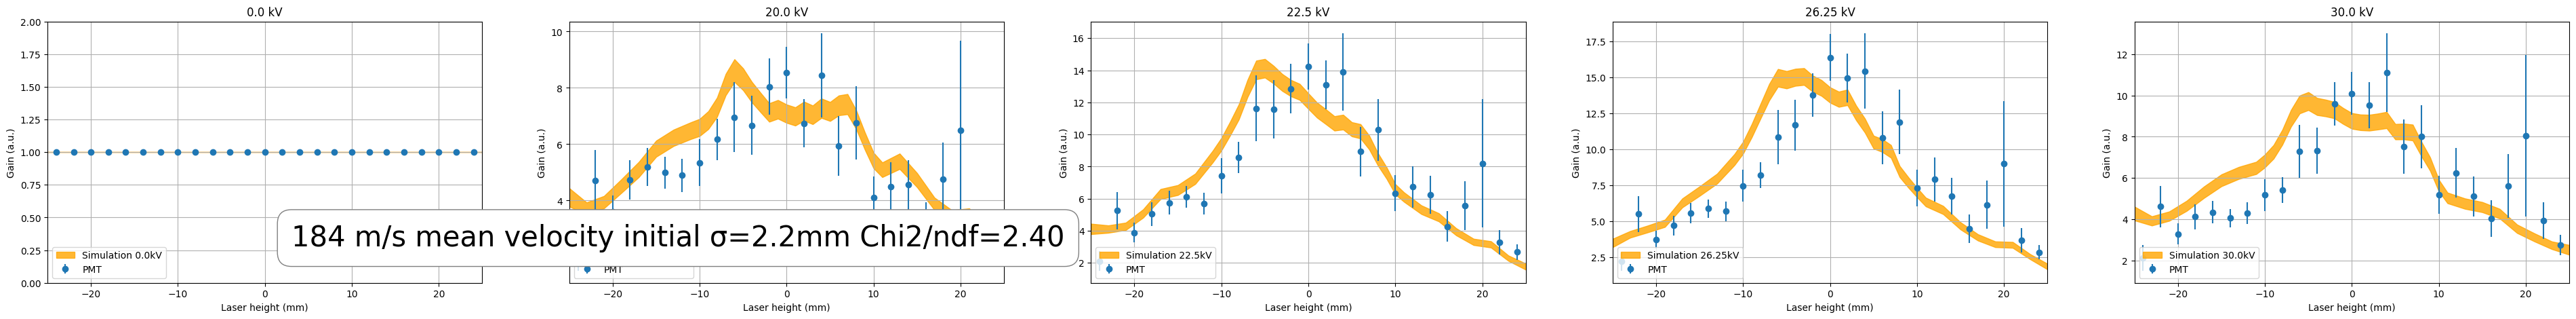

In [31]:
plot_gain(signal_vs_height, signal_vs_height_top, signal_vs_height_bottom, all_final_results, annotation=f'{_v} m/s mean velocity initial σ={(float(sigma)*1000):.1f}mm', h0=25)


In [32]:
gains = []
for hv_voltage in final_result.keys():
    heights = np.array(list(final_result[hv_voltage].keys()))
    mask = np.array(abs(heights)) < 10.0e-3
    signals = np.array(list(final_result[hv_voltage].values()))[mask]
    # print(f"HV {hv_voltage} V: {signals}")
    gains.append(np.mean(signals))
gains = np.array([g/gains[0] for g in gains])
print([round(g.n, 2) for g in gains])
print([round(g.s, 2) for g in gains])

[1.0, 7.32, 11.45, 12.56, 8.58]
[0.0, 0.08, 0.11, 0.12, 0.09]


In [12]:
signals

array([0.0488+/-0.0068, 0.129+/-0.0046, 0.149+/-0.0036, 0.176+/-0.0035,
       0.194+/-0.0028, 0.206+/-0.0052, 0.277+/-0.0052, 0.319+/-0.0073,
       0.352+/-0.01, 0.42+/-0.012, 0.442+/-0.011, 0.535+/-0.0053,
       0.514+/-0.016, 0.524+/-0.019, 0.55+/-0.013], dtype=object)

In [16]:
gains = []
for hv_voltage in signal_vs_height.keys():
    heights = np.array(list(signal_vs_height[hv_voltage].keys()))
    mask = np.array(abs(heights-25)) < 5
    signals = np.array(list(signal_vs_height[hv_voltage].values()))[mask]
    # print(f"HV {hv_voltage} V: {signals}")
    gains.append(np.mean(signals))
gains = np.array([g/gains[0] for g in gains])
print([round(g.n, 2) for g in gains])
print([round(g.s, 2) for g in gains])

[1.0, 7.12, 12.17, 13.34, 8.8]
[0.0, 0.27, 0.43, 0.42, 0.29]
